In [ ]:
import pandas as pd

In [ ]:
df= pd.read_csv(r'C:\Users\met00546\formation\Projet data analysis\data_sales adidas.csv')

In [ ]:
print(df.head())

In [ ]:
print(df.info())

In [ ]:
df.describe()

In [ ]:
df[['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit']].head()


In [ ]:
cols_numeric = [
    'Price per Unit',
    'Units Sold',
    'Total Sales',
    'Operating Profit'
]

for col in cols_numeric:
    df[col] = (
        df[col]
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )


In [ ]:
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])


In [ ]:
df.isnull().sum()

In [ ]:
df.loc[df['Price per Unit'].isna(), 
       ['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Sales Method']]


In [ ]:
mask = df['Price per Unit'].isna()
df.loc[mask,'Price per Unit'] =( df.loc[mask,'Total Sales'] / df.loc[mask,'Units Sold'])

In [ ]:
df.loc[mask, ['Price per Unit', 'Units Sold', 'Total Sales']]


In [ ]:
df.isna().sum()


In [ ]:
df.columns

In [ ]:
print(df['Retailer'].unique())

In [ ]:
print(df['Region'].unique())

In [ ]:
print(df['State'].unique())

In [ ]:
print(df['Product'].unique())

In [ ]:
df['Product']= (df['Product']
                .str.strip()
                .str.title()
                .replace(r'\s+', ' ', regex=True)
                .replace("Aparel", "Apparel", regex=True))

In [ ]:
df['City'].unique()

In [ ]:
print(f"Nombre de marques distinctes après mappage : {df['City'].nunique()}")

In [ ]:
df['Sales Method'].unique()

In [31]:
# Filtrer les lignes où Units Sold, Total Sales et Operating Profit sont tous nuls
lignes_zero = df[(df['Units Sold'] == 0) & 
                 (df['Total Sales'] == 0) & 
                 (df['Operating Profit'] == 0)]

# Afficher les lignes correspondantes
print(lignes_zero)

# Si tu veux juste le nombre de ces lignes
print(f"Nombre de lignes avec valeurs nulles : {len(lignes_zero)}")


Empty DataFrame
Columns: [Retailer, Retailer ID, Invoice Date, Region, State, City, Product, Price per Unit, Units Sold, Total Sales, Operating Profit, Sales Method]
Index: []
Nombre de lignes avec valeurs nulles : 0


In [30]:
# Supprimer les lignes où Units Sold, Total Sales et Operating Profit sont tous nuls
df = df[~((df['Units Sold'] == 0) & 
          (df['Total Sales'] == 0) & 
          (df['Operating Profit'] == 0))]

# Vérifier que les lignes ont été supprimées
print(df.shape)


(9637, 12)


In [32]:
df.columns

Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Sales Method'],
      dtype='object')

In [33]:
import matplotlib.pyplot as plt
%matplotlib inline


<Figure size 1200x800 with 0 Axes>

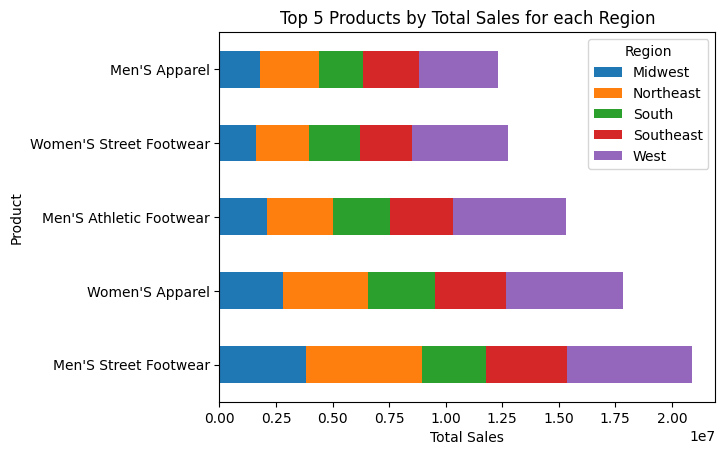

In [34]:
# Agrégation par Product et Region
df_product_region = (
    df.groupby(['Product', 'Region'])['Total Sales']
      .sum()
      .unstack(fill_value=0)
)

# Sélection du Top 5 produits (Total Sales)
top5_products = df_product_region.sum(axis=1).sort_values(ascending=False).head(5).index

df_top5 = df_product_region.loc[top5_products]

# Graphique
plt.figure(figsize=(12,8))
df_top5.plot(kind='barh', stacked=True)
plt.title('Top 5 Products by Total Sales for each Region')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.legend(title='Region')
plt.show()

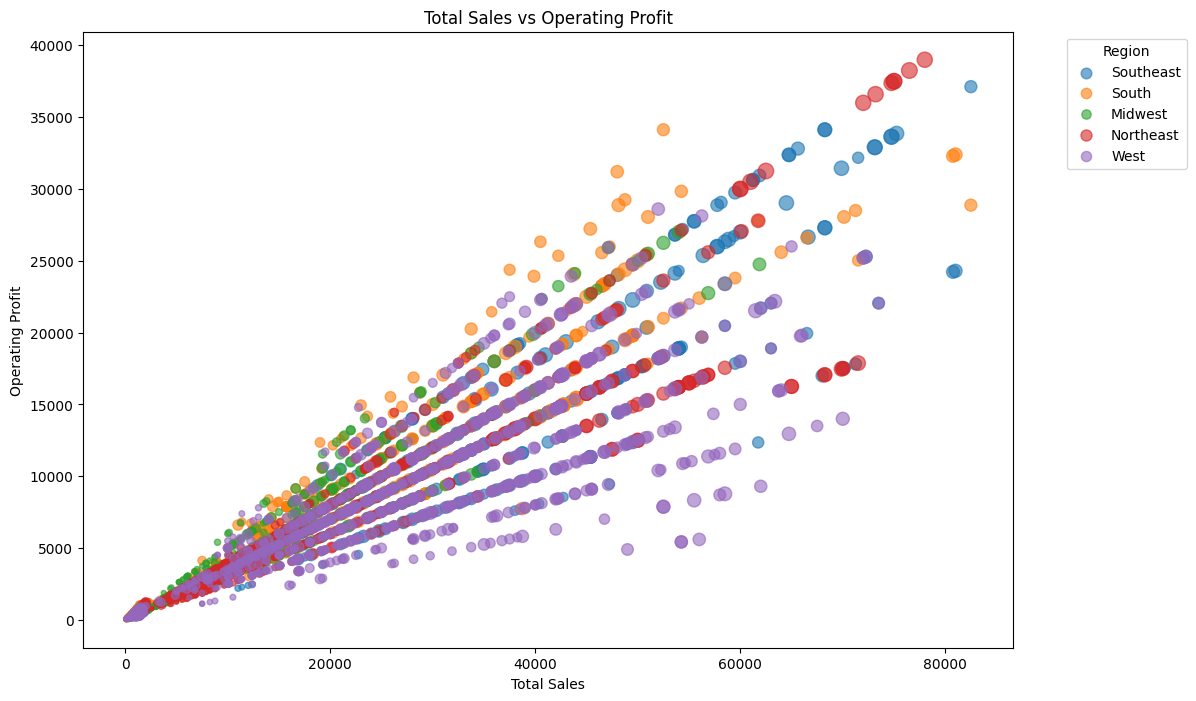

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# Couleurs par Region
regions = df['Region'].unique()
colors = plt.cm.tab10.colors  # palette de 10 couleurs
color_map = {region: colors[i % len(colors)] for i, region in enumerate(regions)}

for region in regions:
    subset = df[df['Region'] == region]
    plt.scatter(
        subset['Total Sales'], 
        subset['Operating Profit'],
        s=subset['Units Sold']*0.1,  # taille des points proportionnelle aux units sold
        color=color_map[region],
        alpha=0.6,
        label=region
    )

plt.title('Total Sales vs Operating Profit')
plt.xlabel('Total Sales')
plt.ylabel('Operating Profit')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


C:\Users\met00546\AppData\Local\Temp\ipykernel_30916\3192444770.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=regions, patch_artist=True)


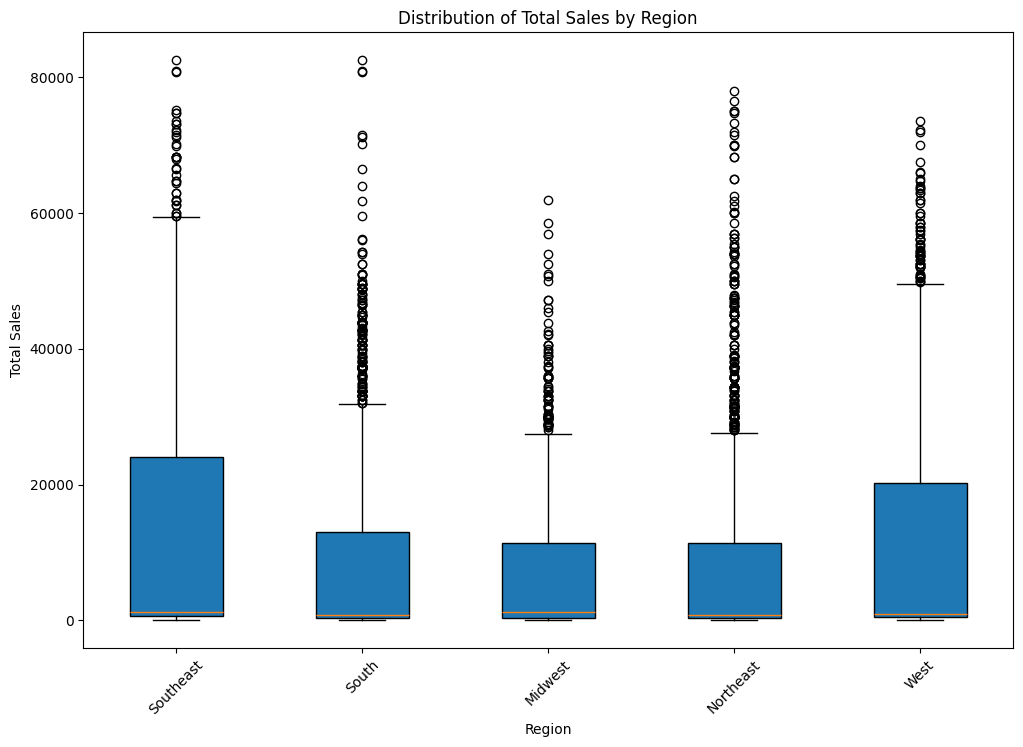

In [36]:
import matplotlib.pyplot as plt

# Préparer les données : liste de Total Sales pour chaque région
regions = df['Region'].unique()
data = [df[df['Region'] == region]['Total Sales'] for region in regions]

plt.figure(figsize=(12,8))
plt.boxplot(data, labels=regions, patch_artist=True)
plt.title('Distribution of Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


C:\Users\met00546\AppData\Local\Temp\ipykernel_30916\2010348220.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=methods, patch_artist=True)


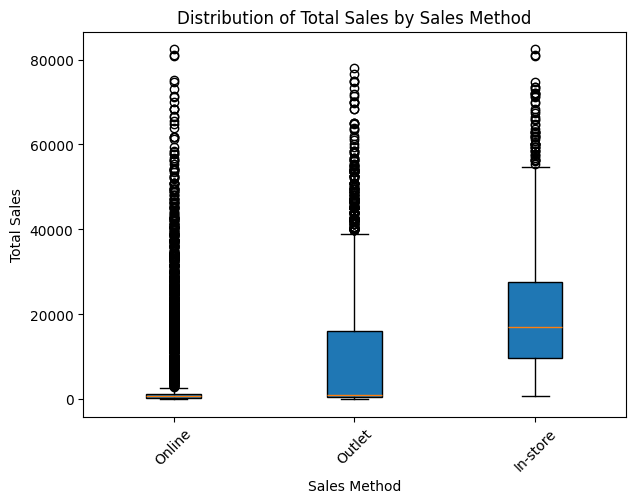

In [45]:
import matplotlib.pyplot as plt

# Préparer les données : liste de Total Sales pour chaque méthode de vente
methods = df['Sales Method'].unique()
data = [df[df['Sales Method'] == method]['Total Sales'] for method in methods]

plt.figure(figsize=(7,5))
plt.boxplot(data, labels=methods, patch_artist=True)
plt.title('Distribution of Total Sales by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)  # rotation pour mieux lire les noms
plt.show()


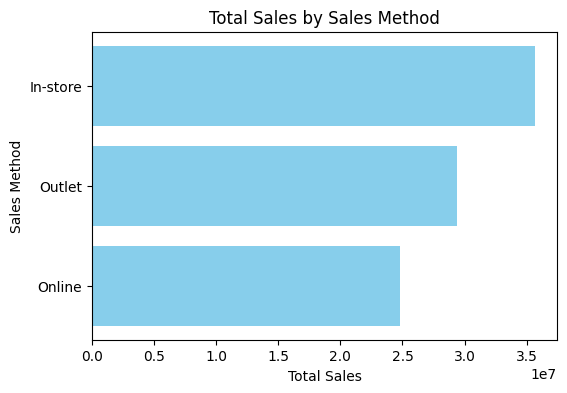

In [44]:
import matplotlib.pyplot as plt

# Agrégation des ventes par Sales Method
sales_method = df.groupby('Sales Method')['Total Sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(6,4))
plt.barh(sales_method.index, sales_method.values, color='skyblue')
plt.title('Total Sales by Sales Method')
plt.xlabel('Total Sales')
plt.ylabel('Sales Method')
plt.show()


In [39]:
corr = df[['Price per Unit','Units Sold','Total Sales','Operating Profit']].corr()
print(corr)


                  Price per Unit  Units Sold  Total Sales  Operating Profit
Price per Unit          1.000000    0.265418     0.435338          0.394311
Units Sold              0.265418    1.000000     0.913500          0.892586
Total Sales             0.435338    0.913500     1.000000          0.956589
Operating Profit        0.394311    0.892586     0.956589          1.000000


C:\Users\met00546\AppData\Local\Temp\ipykernel_30916\3982446116.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Invoice Date')['Total Sales'].sum()


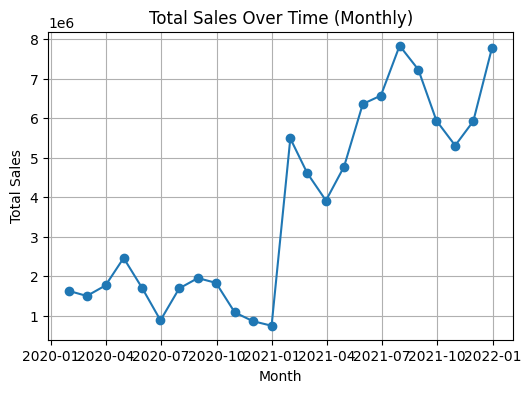

In [42]:

# Grouper par mois et sommer Total Sales
monthly_sales = df.resample('M', on='Invoice Date')['Total Sales'].sum()

# Graphique
plt.figure(figsize=(6,4))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-')
plt.title('Total Sales Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [52]:
total_sales = df['Total Sales'].sum()
total_profit = df['Operating Profit'].sum()
print(f"Total Sales: {total_sales} $ \nTotal Profit: {total_profit} $")


Total Sales: 89820067.0 $ 
Total Profit: 33158084.0 $


In [ ]:
avg_sales = df['Total Sales'].mean()
avg_profit = df['Operating Profit'].mean()
print(f"Average Sales per transaction: {avg_sales}\nAverage Profit: {avg_profit}")




Average Sales per transaction: 9320.334855245408
Average Profit: 3440.7060288471516


In [56]:
top_products = df.groupby('Product')['Units Sold'].sum().sort_values(ascending=False).head(5)
print(top_products)


Product
Men'S Street Footwear        593320.0
Men'S Athletic Footwear      434451.0
Women'S Apparel              433127.0
Women'S Street Footwear      391444.0
Women'S Athletic Footwear    317136.0
Name: Units Sold, dtype: float64


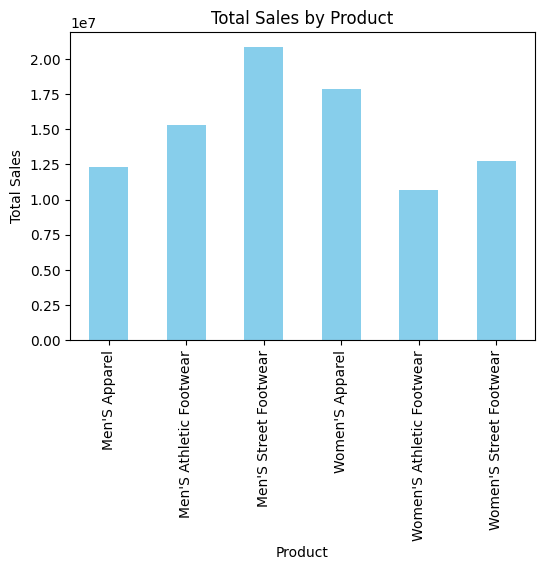

In [59]:
import matplotlib.pyplot as plt

# Somme des ventes par produit
sales_by_product = df.groupby('Product')['Total Sales'].sum()

# Graphique
plt.figure(figsize=(6,4))
sales_by_product.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.show()
